In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import statistics
import numpy as np
pathToFolder = ""
plt.rcParams.update({'font.size': 10})

results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

all_throughput_results = []
all_median_fairness_results = []
all_max_fairness_results = []
all_time_results = []
all_first2_results = []

util_with_udp_array = []

labels = []

fifo_or_cebinae = ""

In [2]:
def plot():
    # throughput calculation
    time_1 = []
    time_2 = []
    time_3 = []
    time_4 = []
    throughput_array_1 = []
    throughput_array_2 = []
    throughput_array_3 = []
    throughput_array_4  = []
    throughput_array_udp = []
    packet_drop_1 = []
    packet_drop_2 = []
    packet_drop_3 = []
    packet_drop_4 = []
            
    # if any file is does not have entries that go until [duration--30s], print error and change experiments    
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-1.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        if (last_time_of_file < 29):
            print("error in file 0-0-1.out")
            print(last_time_of_file)
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        last_line_of_file = rf.readlines()[-1]
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-2.out")
            print(last_time_of_file)

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-3.out")
            print(last_time_of_file)

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-4.out")
            print(last_time_of_file)

    ################################################ throughput ###########################################################
    # # # # # # # # # # # # # # # # # # # # # # # #  four flows # # # # # # # # # # # # # # # # # # # # # # # # # # #

    time_total_throughput = []
    total_throughput_array = []

    prev_recorded_time: float = 0
    total_time: float = 0
    total_size: float = 0
    time_index = 0.1
    total_throughput_array = []

    # total throughput

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-full-throughput-sorted.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size


            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_total_throughput.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)


                total_throughput_array.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time


    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now

    # throughput 1
    prev_seq_number: float = 0
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-1.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_1.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size


            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_1.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)


                throughput_array_1.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    # throughput 2

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            # bookmark first_index_in_array_from_data_2 for throughput calculations later (measuring throughput of first second)
            first_index_in_array_from_data_2 = first_index_in_array_from_data
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_2.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_2.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_2.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    inserted_all_new_indices = False
    # compare time_index (0.1) to first time in file 0-0-2 (time when first packet is received)
    while (time_index < first_index_in_array_from_data):
        # insert time_index in time array to fill time (to match length of time_1)--match flow start time
        time_2.insert(index, round(time_index, 2))
        throughput_array_2.insert(index, 0)
        index += 1
        time_index += 0.1
        # when time_index has reached the first time in the file (when flow starts), stop inserting new values
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    # if flow stops just before 29.9 (between 19 and 29.9--see above for error for flow stopping before 19s)
    # append time_index and throughput = 0 until array lengths are the same
    last_time_index = time_2[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_2.append(round(last_time_index, 2))
        throughput_array_2.append(0)


    # throughput 3

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_3.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_3.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_3.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_3.insert(index, round(time_index, 2))
        throughput_array_3.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_3[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_3.append(round(last_time_index, 2))
        throughput_array_3.append(0)

    # throughput 4

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_4.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_4.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_4.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_4.insert(index, round(time_index, 2))
        throughput_array_4.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_4[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_4.append(round(last_time_index, 2))
        throughput_array_4.append(0)
  
    # udp
        # udp
    time_udp_1 = []
    throughput_array_udp_1 = []
    time_udp_2 = []
    throughput_array_udp_2 = []
    time_udp_3 = []
    throughput_array_udp_3 = []
        
    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-12-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-12-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_1.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_1.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_1.insert(index, round(time_index, 2))
        throughput_array_udp_1.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_1[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_1.append(round(last_time_index, 2))
        throughput_array_udp_1.append(0)

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-13-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-13-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_2.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_2.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_2.insert(index, round(time_index, 2))
        throughput_array_udp_2.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_2[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_2.append(round(last_time_index, 2))
        throughput_array_udp_2.append(0)

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-14-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-14-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_3.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_3.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_3.insert(index, round(time_index, 2))
        throughput_array_udp_3.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_3[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_3.append(round(last_time_index, 2))
        throughput_array_udp_3.append(0)
        
        
#      # udp
#     time_udp = []
#     throughput_array_udp = []
        
#     prev_time = 0
#     total_time = 0
#     total_size = 0
#     prev_recorded_time = 0
#     last_time = 0
#     time_index = 0.1 # not used right now
#     first_index_in_array_from_data = 0
#     # used to calculate where time_index should be
#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-6.out', 'r') as rf:
#         for line in rf:
#             time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
#             first_index_in_array_from_data = time_index
#             break
#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-6.out', 'r') as rf:
#         for line in rf:
#             # current time
#             total_time = float(line.split(" IP", 1)[0])

#             # current size
#             currentLineToSplit = line.split("length ", 1)[1]
#             if (line.split("length ", 1)[1].__contains__(":")):
#                 size = int(currentLineToSplit.split(": HTTP")[0]) + 40
#             else:
#                 size = int(line.split("length ", 1)[1]) + 28
#             size = size * 8
#             total_size += size

#             if (total_time >= time_index):

#                 # add 100 ms interval to time array
#                 time_udp.append(round(time_index, 2))

#                 # add throughput to throughput array
#                 throughput = (total_size - size) / 0.1 # throughput (size / time)

#                 throughput_array_udp.append(throughput / 1000000) # convert bps to Mbps

#                 time_index += 0.1
#                 total_size = size
#                 prev_recorded_time = last_time
#             last_time = total_time

#         time_index = 0.1
#     index = 0
#     while (time_index < first_index_in_array_from_data):
#         time_udp.insert(index, round(time_index, 2))
#         throughput_array_udp.insert(index, 0)
#         index += 1
#         time_index += 0.1
#         if (time_index == first_index_in_array_from_data):
#             inserted_all_new_indices = True

#     last_time_index = time_udp[-1]
#     while (last_time_index < last_time_of_file):
#         last_time_index += 0.1
#         time_udp.append(round(last_time_index, 2))
#         throughput_array_udp.append(0)

#     ############################### queue #######################################################
#     line_number = 0
#     prev_sign = "-"
#     duplicate_line = 0 

#     dropped_packets = [] # array that contains all times where packets were dropped
#     dropped_packets_markers = []
#     prev_time = 0

#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-full_sorted_duplicates_TCP.out', 'r') as file:
#         for line in file:
#             line_number += 1
#             adjusted_size = 0

#             sign = line.split(" ", 1)[0]
#             temp_time = line.split(" IP", 1)[0]
#             time = float(temp_time.split(" ")[1])

#             # find size to add to queue
#             currentLineToSplit = line.split("length ", 1)[1]
#             if (line.split("length ", 1)[1].__contains__(":")):
#                 size = int(currentLineToSplit.split(": HTTP")[0]) + 40
#             else:
#                 size = int(line.split("length ", 1)[1]) + 28

#             size = size * 8
#             adjusted_size += size
#             # if it's TCP traffic, check that signs do not match
#             if (not line.__contains__("UDP")):
#                 if (prev_sign == "-" and sign != "+"):
#                     duplicate_line += 1
#                     dropped_packets.append(line)
#                     dropped_packets_markers.append(prev_time)
#                 elif (prev_sign == "+" and sign != "-"):
#                     duplicate_line += 1
#                     dropped_packets.append(line)
#                     dropped_packets_markers.append(prev_time)

#             prev_sign = sign
#             prev_line = line
#             prev_time = time

    # total with all udp

    total_throughput_with_all_udp = []
    

#     for index in range (0, len(time_1)):
#         total_throughput_with_all_udp.append(total_throughput_array[index] + throughput_array_udp_1[index] + throughput_array_udp_2[index] + throughput_array_udp_3[index])

            
    # creating new np arrays so that slice operation can be performed
    np_array_1 = np.array(throughput_array_1)
    np_array_2 = np.array(throughput_array_2)
    np_array_3 = np.array(throughput_array_3)
    np_array_4 = np.array(throughput_array_4)  
    
#     np_throughput_array_udp = np.array(throughput_array_udp)

    # calculate ratio between max/min of four flows using slicing window
    for index in range(40, len(time_1)):
        # slice syntax: basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
        throughput_mean_array = np.array([statistics.mean(np_array_1[index:index + 20:1]), statistics.mean(np_array_2[index:index + 20:1]), statistics.mean(np_array_3[index:index + 20:1]), statistics.mean(np_array_4[index:index + 20:1])])
        max = throughput_mean_array.max()
        min = throughput_mean_array.min()
        if (min != 0):
            ratio = max / min
        else:
            ratio = 0

    # find utilization from 6s--> (total throughput)
    utilization_array_total_throughput = []
    for index in range (60, len(time_1)):  
#         utilization_array_total_throughput.append(np_throughput_array_udp[index] + throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
        utilization_array_total_throughput.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
    util_after_60_total_throughput = statistics.mean(utilization_array_total_throughput)
#     print("utilization 6s--> (total throughput): " + str(statistics.mean(utilization_array_total_throughput)))

    # find utilization of last 5 seconds
    utilization_array = []
    for index in range (len(time_1) - 50, len(time_1)):  
#         utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index] + throughput_array_udp[index])
        utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
    util_last5 = statistics.mean(utilization_array)
#     print("utilization last 5 seconds: " + str(statistics.mean(utilization_array)))

#     utilization_array_with_udp = []
#     for index in range (len(time_1) - 50, len(time_1)):  
#         utilization_array_with_udp.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index] + throughput_array_udp[index])
# #         utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
#     util_with_udp_last5 = statistics.mean(utilization_array_with_udp)
# #     print("utilization last 5 seconds: " + str(statistics.mean(utilization_array)))
#     util_with_udp_array.append(util_with_udp_last5)


    # calculate throughput of first flow for 0-2s
    utilization_array_0_2s = []
    for index in range (0, time_1.index(round(first_index_in_array_from_data_2, 1))):
        utilization_array_0_2s.append(throughput_array_1[index])
        util_first2 = statistics.mean(utilization_array_0_2s)

    ratio_array = []

    # calculate ratio between max/min of four flows using slicing window for 15s-18s
    for index in range(len(time_1) - 50, len(time_1)):
        # slice syntax: basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
        if ((index + 20) <= len(time_1)): # ensure that there is enough room for slicing window (15-18s)
            throughput_mean_array = np.array([statistics.mean(np_array_1[index:index + 20:1]), statistics.mean(np_array_2[index:index + 20:1]), statistics.mean(np_array_3[index:index + 20:1]), statistics.mean(np_array_4[index:index + 20:1])])

        max = throughput_mean_array.max()
        min = throughput_mean_array.min()
        if (min != 0):
            ratio = max / min
        else:
            ratio = 0
            print("Replace this iteration: ", iteration)
        ratio_array.append(ratio)

    ratio_array_np = np.array(ratio_array)

#     results_throughput.append(statistics.mean(utilization_array_with_udp))
    results_throughput.append(statistics.mean(utilization_array))
    results_median_fairness.append(statistics.median(ratio_array))
    results_max_fairness.append(ratio_array_np.max())
    results_first2.append(util_first2)

    # raw fifo only: assigning Raw FIFO median fairness ratio to be used as constraint
    if (raw_fifo):
        rawFIFOMedianFairnessRatio = statistics.median(ratio_array)
    
#     print("median ratio:", statistics.median(ratio_array))
#     print("max ratio: ", ratio_array_np.max())
#     print("udp:", statistics.median(throughput_array_udp))
    
    if (show_plot):
            ################################### plot throughput--and dropped packets (Mbps) #########################################################
        plt.plot(time_1, throughput_array_1, label="Flow 1")
        plt.plot(time_2, throughput_array_2, label="Flow 2")
        plt.plot(time_3, throughput_array_3, label="Flow 3")
        plt.plot(time_4, throughput_array_4, label="Flow 4")
        plt.plot(time_udp_1, throughput_array_udp_1, label="UDP", color='hotpink', alpha=0.5)
        plt.plot(time_udp_2, throughput_array_udp_2, label="UDP", color='gold', alpha=0.5)
        plt.plot(time_udp_3, throughput_array_udp_3, label="UDP", color='indigo', alpha=0.5)
        plt.plot(time_total_throughput, total_throughput_array, label="Total Throughput", color='black')
#         plt.plot(time_total_throughput, total_throughput_with_all_udp, color='grey')
        plt.plot(packet_drop_1, np.full((len(packet_drop_1)), -3, dtype=int), 'bo') # dropped packets
        plt.plot(packet_drop_2, np.full((len(packet_drop_2)), 3, dtype=int), 'o', color='orange') # dropped packets
        plt.plot(packet_drop_3, np.full((len(packet_drop_3)), 0, dtype=int), 'go') # dropped packets
        plt.plot(packet_drop_4, np.full((len(packet_drop_4)), 6, dtype=int), 'ro') # dropped packets

#     plt.legend(['Flow 1', 'Flow 2', 'Flow 3', 'Flow 4', 'Total Throughput'], loc='upper left', bbox_to_anchor=(1, 1))
        plt.xlabel("Time (s)")
        plt.ylabel("Throughput (Mbps)")
        yticks = np.arange(0, 110, 10)
        plt.yticks(yticks)
    #     plt.title("Tax Constant: " + taxConstant + " Median Fairness: " + str(round(median_fairness, 2)))
        plt.show()
        print("median ratio:", statistics.median(ratio_array))

    return results_throughput, results_median_fairness, results_max_fairness, results_first2

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.66352896
median fairness: 2.1067372187390174
max fairness: 2.326830321471835


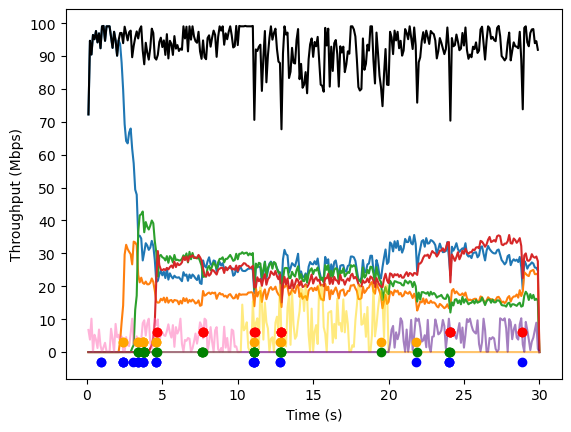

median ratio: 2.091576694786534
median iqr 2.338430892173957 1.690309802093696
maximum iqr 2.478789005632077 2.041943714018822


In [3]:
iteration = 1
taxConstant = "RawFIFO"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = True
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

q75, q50, q25 = np.percentile(results_median_fairness, [75,50, 25])
print("median iqr", q75, q25)
q75, q50, q25 = np.percentile(results_max_fairness, [75,50, 25])
print("maximum iqr", q75, q25)

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.83018496
median fairness: 1.8695755432647747
max fairness: 2.1539721806172807


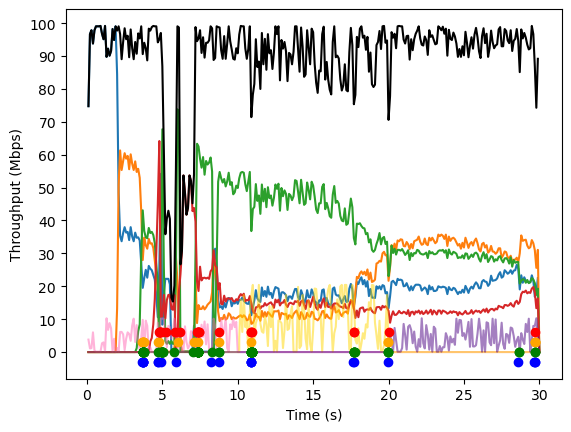

median ratio: 1.9495586866748096


([93.9035136,
  94.3963392,
  95.0248704,
  93.9392256,
  93.6297216,
  93.5797248,
  93.9082752,
  93.8725632,
  93.0726144,
  92.9750016,
  93.9392256],
 [1.7895923998547396,
  4.460650577124869,
  2.6339452978643685,
  1.9495586866748096,
  1.554227099925365,
  1.0985319944193257,
  3.0195251272146493,
  2.171324422843256,
  1.5008673625834001,
  1.3458170023146754,
  1.9495586866748096],
 [1.9056751467710373,
  4.5391487125591174,
  2.642830540037244,
  2.6171236171236174,
  1.614150016377334,
  1.1025845989874767,
  3.1486169714017818,
  2.3327645051194534,
  1.975179856115108,
  1.4811907098462544,
  2.6171236171236174],
 [94.375136,
  92.8389052631579,
  93.68469333333333,
  94.72302222222223,
  93.09578105263158,
  92.03068631578947,
  91.84622222222222,
  94.43203555555556,
  94.006112,
  93.13712,
  94.72302222222223])

In [4]:
iteration = 1
taxConstant = "0.001"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.94303488
median fairness: 1.764337738169476
max fairness: 1.9196209915891949


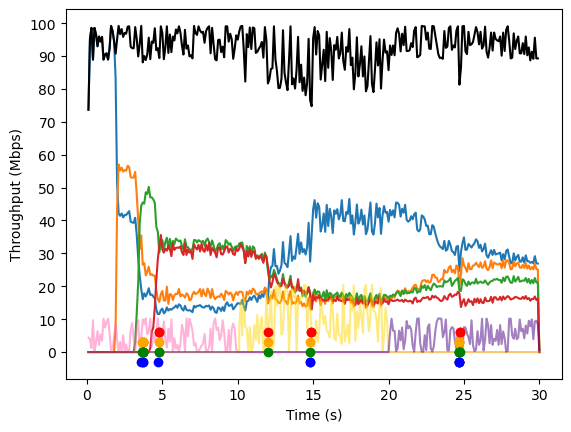

median ratio: 1.7400261801063532


([94.4725248,
  93.1321344,
  93.470208,
  93.6892416,
  93.422592,
  95.5819776,
  94.4391936,
  93.1178496,
  94.4844288,
  93.62019839999999,
  93.6892416],
 [1.7337031900138695,
  1.4811554401461942,
  1.6722529692382144,
  1.7400261801063532,
  3.735690235690236,
  1.6062576836403264,
  1.8376647834274953,
  4.7144402379664685,
  2.1874417504088584,
  1.7886492962325988,
  1.7400261801063532],
 [1.8421431139877742,
  1.5071942446043167,
  1.684970080957409,
  2.05348210850327,
  4.094797687861273,
  1.8644610458911417,
  1.8717167872097449,
  4.768648648648649,
  3.2807197943444733,
  1.967525195968645,
  2.05348210850327],
 [92.85708190476191,
  91.7404088888889,
  92.90155789473684,
  92.9704888888889,
  92.91096888888889,
  92.4602819047619,
  95.244128,
  93.78496,
  91.46926222222223,
  91.86508190476191,
  92.9704888888889])

In [5]:
iteration = 1
taxConstant = "0.005"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.97517568
median fairness: 1.8894037496323157
max fairness: 1.9818226979113205


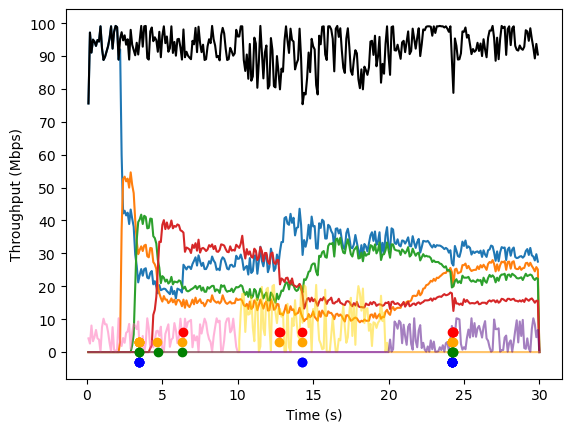

median ratio: 1.9031461236032556


([93.2654592,
  94.4058624,
  94.386816,
  93.6178176,
  94.8796416,
  93.8059008,
  94.4249088,
  94.44157440000001,
  93.54163199999999,
  92.982144,
  94.386816],
 [2.0974119418458272,
  2.1036745406824147,
  1.9031461236032556,
  1.3080643763195388,
  1.8377690457725864,
  1.8756613756613758,
  1.4885682031183438,
  2.0977725249897725,
  1.5874778580888584,
  2.388929569729699,
  1.9031461236032556],
 [2.1478676763650855,
  2.2146596858638743,
  2.043614931237721,
  1.3844259772237613,
  1.8515426497277676,
  1.92003046458492,
  1.5871165644171779,
  2.140031031807603,
  1.806703910614525,
  2.500970873786408,
  2.043614931237721],
 [91.345568,
  94.71637333333334,
  93.36725333333334,
  93.03280761904762,
  93.28222476190476,
  91.67801904761905,
  91.20867199999999,
  93.59073684210526,
  92.99694222222222,
  92.28270222222221,
  93.36725333333334])

In [6]:
iteration = 1
taxConstant = "0.006"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.88518144
median fairness: 2.0413124671718834
max fairness: 2.0499976139291674


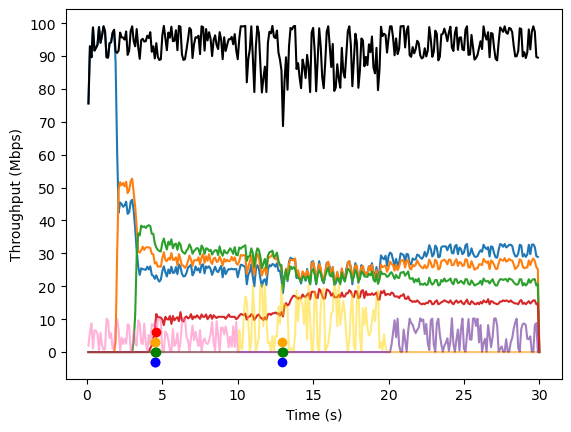

median ratio: 2.040615141955836


([94.1773056,
  93.6297216,
  92.9297664,
  93.8249472,
  93.720192,
  93.946368,
  94.1058816,
  93.57972480000001,
  95.0272512,
  93.910656,
  94.1773056],
 [2.040615141955836,
  1.5582252352264305,
  2.030579529108941,
  2.042009792387931,
  2.026211278792693,
  2.042862356266739,
  2.189297452477991,
  2.0578342550750772,
  2.0644910644910643,
  2.040308241052061,
  2.040615141955836],
 [2.064252336448598,
  2.0512913786831573,
  2.035742652899126,
  2.048703849175177,
  2.046456692913386,
  2.048012593467139,
  2.324254215304799,
  2.1918178309533,
  2.0707895760404513,
  2.0435298773248913,
  2.064252336448598],
 [93.45987555555556,
  92.851424,
  94.05968,
  93.904,
  93.66768761904761,
  92.9591161904762,
  93.619232,
  94.095392,
  91.93670736842105,
  92.46126222222222,
  93.45987555555556])

In [7]:
iteration = 1
taxConstant = "0.008"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.00922112
median fairness: 1.7018516397967538
max fairness: 1.7341684887882072


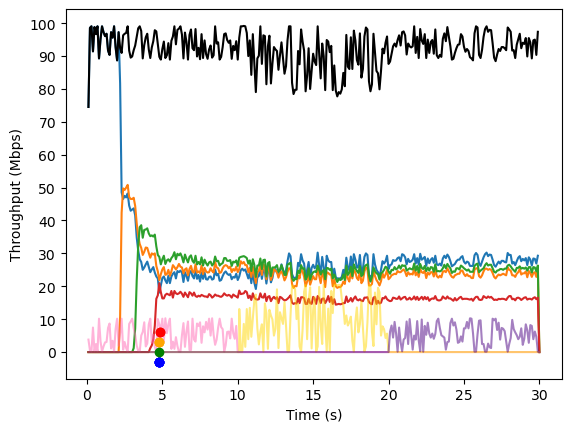

median ratio: 1.71563981042654


([94.5748992,
  93.5940096,
  94.36300800000001,
  94.45824,
  94.1511168,
  93.720192,
  93.5559168,
  94.267776,
  93.4083072,
  93.9987456,
  93.5559168],
 [1.9069400630914828,
  1.5578664877557866,
  1.481382086548138,
  1.6544467073998643,
  1.9001584786053884,
  1.9364951768488747,
  1.71563981042654,
  1.6385852090032156,
  1.6880634691669674,
  1.7202337472607743,
  1.71563981042654],
 [1.9259404388714736,
  1.5601743211532013,
  1.8802588996763752,
  1.6674568235692515,
  1.9146102624363492,
  1.9506420545746388,
  1.7276363636363636,
  1.652591170825336,
  1.698994252873563,
  1.7407006139400505,
  1.7276363636363636],
 [93.71118222222222,
  92.42627047619048,
  92.21653333333333,
  91.940768,
  93.17550222222222,
  93.62233904761905,
  94.4839619047619,
  95.916704,
  93.03312842105264,
  94.59075555555556,
  94.4839619047619])

In [8]:
iteration = 1
taxConstant = "0.01"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.86613504
median fairness: 1.4648911232129616
max fairness: 1.4700893697333086


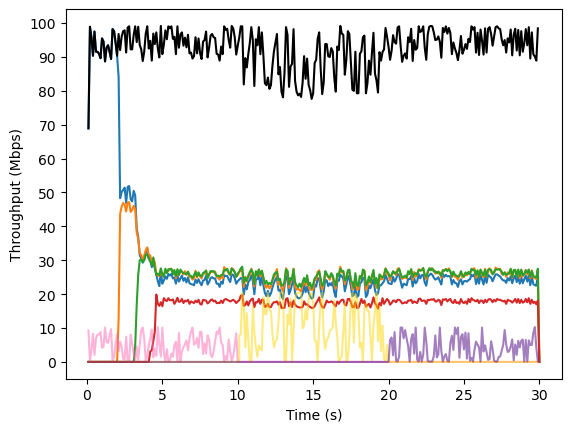

median ratio: 1.4670658682634732


([94.243968,
  93.2702208,
  95.0272512,
  93.6797184,
  93.767808,
  93.7535232,
  94.1082624,
  93.946368,
  93.4178304,
  93.4464,
  95.0272512],
 [1.468864468864469,
  1.460482250502344,
  1.4670658682634732,
  1.4593509534961526,
  1.4674418604651163,
  1.472069353337926,
  1.4578512396694214,
  1.4787767379679144,
  1.461834914415343,
  1.46271637816245,
  1.4670658682634732],
 [1.473022178086726,
  1.4688328912466841,
  1.4730263157894739,
  1.4656895403064625,
  1.4704515272244354,
  1.4794565937707087,
  1.4659841479524438,
  1.4823451032644903,
  1.4683965402528274,
  1.469727212242182,
  1.4730263157894739],
 [90.821792,
  92.19011555555555,
  92.059808,
  92.97612190476191,
  93.3088,
  92.83822222222223,
  91.452704,
  92.13719578947368,
  93.15441454545454,
  92.696672,
  92.059808])

In [9]:
iteration = 1
taxConstant = "0.015"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.07493120000001
median fairness: 1.6155879053547286
max fairness: 1.6228336964221959


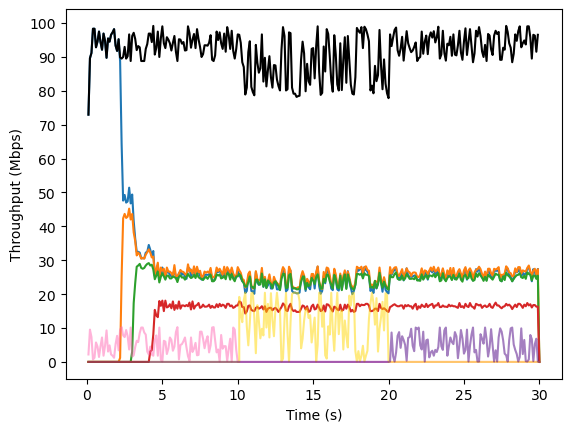

median ratio: 1.614170020529864


([94.5701376,
  94.3392,
  93.7939968,
  93.1345152,
  94.1868288,
  93.50592,
  93.4392576,
  94.6415616,
  94.3915776,
  94.7463168,
  94.3915776],
 [1.6202872686503123,
  1.6171925286778774,
  1.6170057901795936,
  1.6024531024531021,
  1.6104734576757531,
  1.58065084001429,
  1.7801470588235293,
  1.6215933043506898,
  1.614170020529864,
  1.6106924360400443,
  1.614170020529864],
 [1.6233345336694274,
  1.625446747676912,
  1.6277398490837225,
  1.606115107913669,
  1.6223328591749642,
  1.590974212034384,
  1.7992673992673993,
  1.6311651179413866,
  1.6175839885632595,
  1.6211958467597565,
  1.6175839885632595],
 [91.922912,
  92.93288421052631,
  92.83822222222223,
  92.10883047619048,
  94.232288,
  92.75024,
  91.02197894736842,
  91.7602488888889,
  93.59966476190476,
  92.55664761904762,
  93.59966476190476])

In [10]:
iteration = 1
taxConstant = "0.017"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.7594752
median fairness: 2.1161509863603314
max fairness: 2.124743427668041


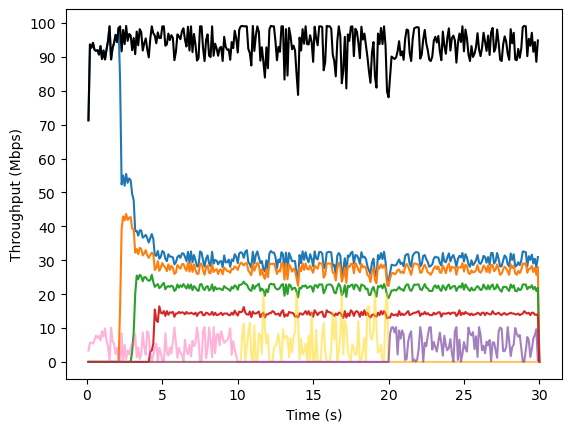

median ratio: 2.1182121971595653


([93.8130432,
  93.16308480000001,
  93.7844736,
  93.91779840000001,
  93.6035328,
  93.7725696,
  93.4773504,
  93.3249792,
  93.9892224,
  94.7486976,
  93.4773504],
 [2.114089775561097,
  1.8671457199567691,
  2.1441303166050796,
  1.8817353407290016,
  1.8770816812053925,
  2.121351125938282,
  2.1182121971595653,
  2.0648979591836736,
  2.1576576576576576,
  2.13670355361596,
  2.1182121971595653],
 [2.1238608119304057,
  1.8745019920318726,
  2.2077551020408164,
  1.88946117274168,
  1.8954869358669832,
  2.132750728256346,
  2.125626043405676,
  2.0798045602605866,
  2.1778865769073845,
  2.1600660066006596,
  2.125626043405676],
 [93.02059789473684,
  93.47495619047619,
  92.000288,
  93.96910222222222,
  92.399072,
  93.35406222222223,
  92.09182476190476,
  90.95306105263158,
  94.05881904761905,
  94.137056,
  92.09182476190476])

In [11]:
iteration = 1
taxConstant = "0.02"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.77590272
median fairness: 2.2002558726435706
max fairness: 2.2201878446886405


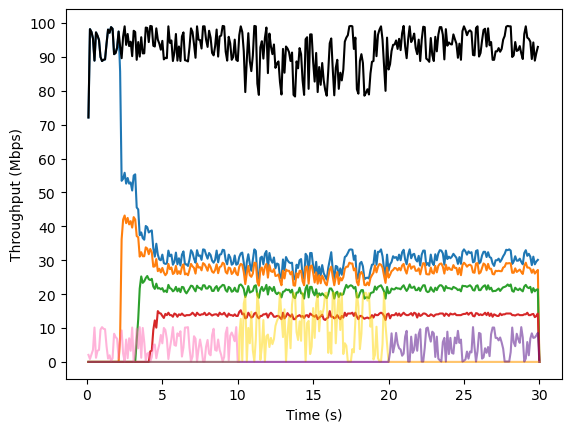

median ratio: 2.2006397862602523


([94.1796864,
  94.029696,
  93.5463936,
  94.255872,
  93.03214080000001,
  92.744064,
  94.5606144,
  94.49395200000001,
  92.9535744,
  93.9630336,
  94.255872],
 [2.224574637011374,
  2.213769655758606,
  1.9407195421095664,
  2.2006397862602523,
  1.9348363577239702,
  2.1876606683804627,
  1.9699309223892725,
  2.2759631490787267,
  2.199871959026889,
  2.2459915611814347,
  2.2006397862602523],
 [2.2411167512690353,
  2.2320067739204066,
  1.9670195439739413,
  2.234970364098222,
  1.9505718954248366,
  2.192208904109589,
  1.986234817813765,
  2.2949251247920133,
  2.2083689154568744,
  2.2749371332774517,
  2.234970364098222],
 [93.2284088888889,
  94.035872,
  92.4348088888889,
  93.16318476190476,
  91.91696,
  91.38990222222222,
  91.51929904761904,
  92.08080842105264,
  92.53400888888889,
  92.178848,
  93.16318476190476])

In [12]:
iteration = 1
taxConstant = "0.021"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.97874688
median fairness: 2.704692139949641
max fairness: 2.722723001498025


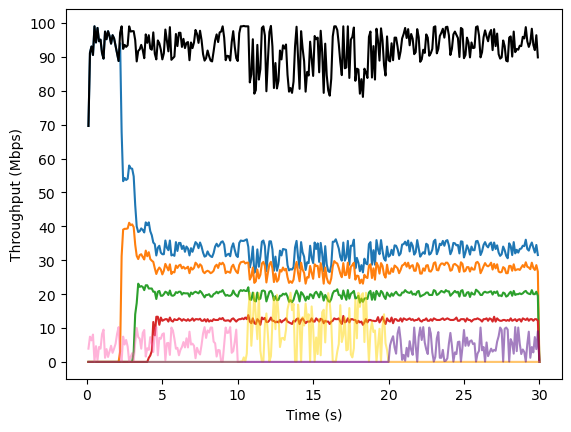

median ratio: 2.702870813397129


([93.898752,
  94.124928,
  94.5725184,
  94.75584,
  92.8654848,
  93.6511488,
  93.4559232,
  94.3915776,
  93.7487616,
  94.3225344,
  93.898752],
 [2.702870813397129,
  2.6850961538461537,
  2.7201619496912226,
  2.7225531432201273,
  2.665221579961465,
  2.7186765173180802,
  2.686481303930968,
  2.708969465648855,
  2.7065134665021526,
  2.697417090525219,
  2.702870813397129],
 [2.7183031458531937,
  2.7122370936902485,
  2.7362167300380227,
  2.7278360343183983,
  2.673076923076923,
  2.7334602570204662,
  2.703154875717017,
  2.727142857142857,
  2.718095238095238,
  2.728829686013321,
  2.7183031458531937],
 [92.96478476190477,
  95.01921684210527,
  92.37528888888889,
  93.696608,
  93.69134222222222,
  92.89904,
  91.86606222222223,
  92.53964190476191,
  91.077728,
  91.61475555555556,
  92.96478476190477])

In [13]:
iteration = 1
taxConstant = "0.025"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.04945664
median fairness: 3.1981852188858557
max fairness: 3.2253968253968255


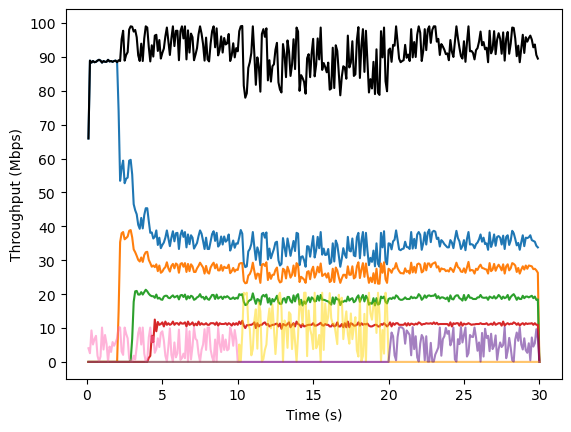

median ratio: 3.1900212314225054


([93.577344,
  93.874944,
  95.0558208,
  94.5344256,
  95.041536,
  93.910656,
  93.517824,
  94.1439744,
  92.744064,
  94.0939776,
  93.577344],
 [3.1900212314225054,
  3.2063492063492065,
  3.2480228466118013,
  3.2206346078044934,
  3.2072521522733393,
  3.1851458885941644,
  3.2150224259161333,
  3.161255987227249,
  3.1316083677676527,
  3.1796911388970543,
  3.1900212314225054],
 [3.2105820105820113,
  3.223809523809524,
  3.256585879873551,
  3.23320994182972,
  3.2673684210526313,
  3.2130365659777422,
  3.2304439746300213,
  3.2222222222222228,
  3.199575371549894,
  3.2269841269841275,
  3.2105820105820113],
 [87.583904,
  87.47480888888889,
  87.55696761904763,
  87.387488,
  87.63152,
  87.38883555555556,
  87.51248,
  87.44174222222222,
  87.63065904761905,
  87.63065904761905,
  87.583904])

In [14]:
iteration = 1
taxConstant = "0.03"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.12064256
median fairness: 4.724172408259139
max fairness: 4.787110257157427


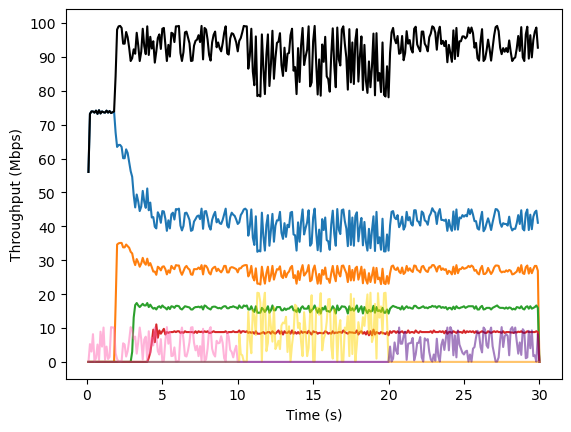

median ratio: 4.7239512855209735


([93.7582848,
  93.4559232,
  94.9153536,
  93.8654208,
  93.9058944,
  94.422528,
  94.75584,
  93.7725696,
  94.113024,
  94.2415872,
  93.7582848],
 [4.7239512855209735,
  4.695047489823609,
  4.815860215053763,
  4.724393530997304,
  4.774140132034868,
  4.719811266960585,
  4.725675675675675,
  4.762304436708607,
  4.6882591093117405,
  4.722745625841184,
  4.7239512855209735],
 [4.764507422402159,
  4.78581081081081,
  4.863087248322148,
  4.7473045822102415,
  4.79689608636977,
  4.798657718120805,
  4.881208053691275,
  4.788409703504044,
  4.765100671140939,
  4.780997304582209,
  4.764507422402159],
 [72.76014222222221,
  72.876512,
  72.68078222222222,
  69.757664,
  72.79006315789474,
  69.84835047619048,
  72.79632842105264,
  72.93205333333333,
  69.757664,
  69.63203555555556,
  72.76014222222221])

In [15]:
iteration = 1
taxConstant = "0.04"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.94612992
median fairness: 6.28857826784787
max fairness: 6.365481783067127


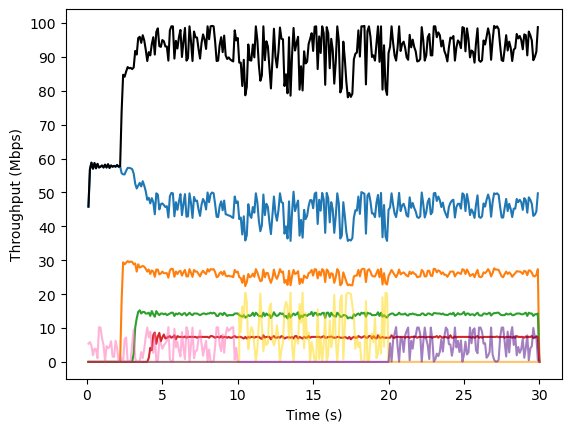

median ratio: 6.290113452188006


([93.7249536,
  94.22016,
  94.7106048,
  93.4654464,
  93.86542080000001,
  94.17730560000001,
  92.9059584,
  94.1201664,
  93.5249664,
  94.7463168,
  93.86542080000001],
 [6.261352466036815,
  6.322006472491909,
  6.439967767929089,
  6.208685933574664,
  6.290113452188006,
  6.287043083507735,
  6.2475649350649345,
  6.310679611650485,
  6.246353322528362,
  6.338187702265372,
  6.290113452188006],
 [6.390953150242327,
  6.39967637540453,
  6.50402576489533,
  6.33063209076175,
  6.319579288025889,
  6.3822580645161295,
  6.294975688816855,
  6.348705501618123,
  6.299352750809061,
  6.493548387096775,
  6.319579288025889],
 [57.20176761904762,
  57.101844210526316,
  57.19609904761905,
  57.164496842105265,
  57.19609904761905,
  57.181088,
  57.11960888888889,
  57.222752,
  57.08654222222222,
  57.15728,
  57.19609904761905])

In [16]:
iteration = 1
taxConstant = "0.05"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

In [17]:
iqr_throughput = []
iqr_median_fairness = []
iqr_max_fairness = []
iqr_time = []
iqr_util_first2 = []

q25_throughput = []
q25_median_fairness = []
q25_max_fairness = []
q25_time = []
q25_util_first2 = []

q75_throughput = []
q75_median_fairness = []
q75_max_fairness = []
q75_time = []
q75_util_first2 = []

q50_throughput = []
q50_median_fairness = []
q50_max_fairness = []
q50_time = []
q50_util_first2 = []

throughput_upper_error = []
median_fairness_upper_error = []
max_fairness_upper_error = []
util_first2_upper_error = []

throughput_lower_error = []
median_fairness_lower_error = []
max_fairness_lower_error = []
util_first2_lower_error = []


print(len(labels))

new_labels = []
for index in range(0, len(labels)):
#     new_labels.append(str(int(labels[index]) / 1000000000))
    new_labels.append(labels[index])
    
print(new_labels)
    
df_throughput = pd.DataFrame({label: result for label, result in zip(labels, all_throughput_results)})

df_median_fairness = pd.DataFrame({label: result for label, result in zip(labels, all_median_fairness_results)})

df_max_fairness = pd.DataFrame({label: result for label, result in zip(labels, all_max_fairness_results)})

df_util_first2 = pd.DataFrame({label: result for label, result in zip(labels, all_first2_results)})


#calculate interquartile range of values of throughput, fairness, time and store in iqr array
for value in labels:
    q75, q50, q25 = np.percentile(df_throughput[str(value)], [75,50, 25])
    iqr = q75 - q25
    iqr_throughput.append(iqr)
    q25_throughput.append(q25)
    q50_throughput.append(q50)
    q75_throughput.append(q75)

    q75, q50, q25 = np.percentile(df_median_fairness[value], [75,50, 25])
    iqr = q75 - q25
    iqr_median_fairness.append(iqr)
    q25_median_fairness.append(q25)
    q50_median_fairness.append(q50)
    q75_median_fairness.append(q75)
    
    q75, q50, q25 = np.percentile(df_max_fairness[value], [75,50, 25])
    iqr = q75 - q25
    iqr_max_fairness.append(iqr)
    q25_max_fairness.append(q25)
    q50_max_fairness.append(q50)
    q75_max_fairness.append(q75)
    
    q75, q50, q25 = np.percentile(df_util_first2[value], [75,50, 25])
    iqr = q75 - q25
    iqr_util_first2.append(iqr)
    q25_util_first2.append(q25)
    q50_util_first2.append(q50)
    q75_util_first2.append(q75)
    
for value in labels:
    throughput_upper_error.append(q75_throughput[labels.index(value)] - q50_throughput[labels.index(value)])
    throughput_lower_error.append(q50_throughput[labels.index(value)] - q25_throughput[labels.index(value)])
    
    median_fairness_upper_error.append(q75_median_fairness[labels.index(value)] - q50_median_fairness[labels.index(value)])
    median_fairness_lower_error.append(q50_median_fairness[labels.index(value)] - q25_median_fairness[labels.index(value)])

    max_fairness_upper_error.append(q75_max_fairness[labels.index(value)] - q50_max_fairness[labels.index(value)])
    max_fairness_lower_error.append(q50_max_fairness[labels.index(value)] - q25_max_fairness[labels.index(value)])
    
    util_first2_upper_error.append(q75_util_first2[labels.index(value)] - q50_util_first2[labels.index(value)])
    util_first2_lower_error.append(q50_util_first2[labels.index(value)] - q25_util_first2[labels.index(value)])

13
['0.001', '0.005', '0.006', '0.008', '0.01', '0.015', '0.017', '0.02', '0.021', '0.025', '0.03', '0.04', '0.05']


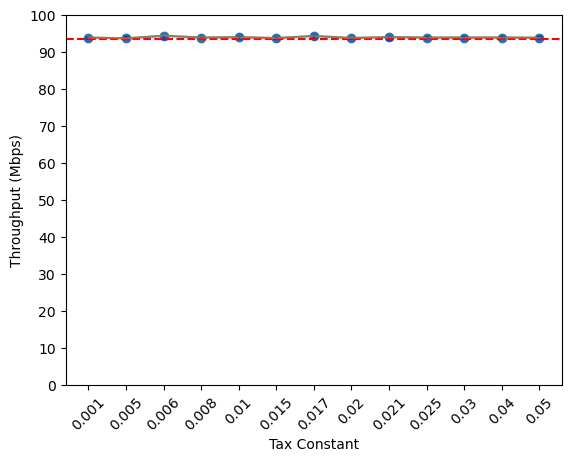

<Figure size 550x200 with 0 Axes>

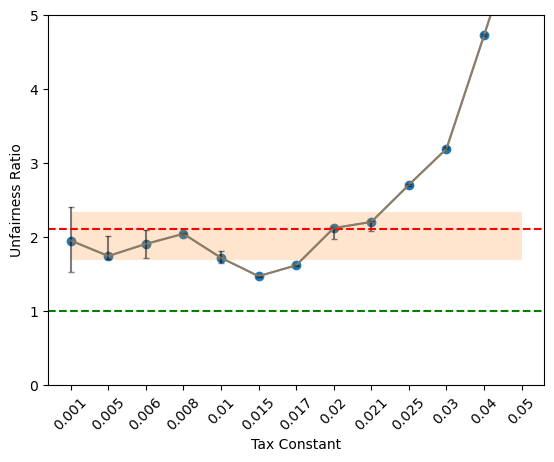

<Figure size 550x200 with 0 Axes>

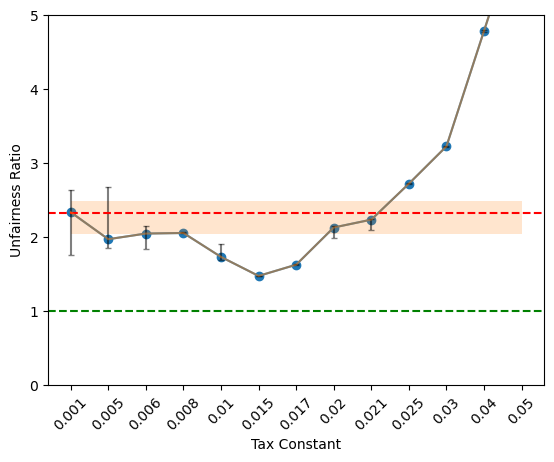

<Figure size 550x200 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [18]:
######################### Tax Constant vs Throughput  ###############
plt.xlabel('Tax Constant')
plt.ylabel('Throughput (Mbps)')
plt.scatter(new_labels, q50_throughput)
# # plt.scatter(new_labels, q50_util_first2)
plt.plot(new_labels, q50_throughput)
# plt.plot(new_labels, q50_util_first2)
plt.errorbar(new_labels, q50_throughput, yerr=[throughput_lower_error, throughput_upper_error], alpha=0.5, ecolor='blue', capsize=2)
# plt.errorbar(new_labels, q50_util_first2, yerr=[util_first2_lower_error, util_first2_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = throughput_median_rawfifo, color = 'r', linestyle = 'dashed')
yticks = np.arange(0, 110, 10)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()

######################### Tax Constant vs Median Fairness Ratio ###############
plt.xlabel('Tax Constant')
plt.ylabel('Unfairness Ratio')
plt.scatter(new_labels, q50_median_fairness)
plt.plot(new_labels, q50_median_fairness)
plt.errorbar(new_labels, q50_median_fairness, yerr=[median_fairness_lower_error, median_fairness_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = fairness_median_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = 1, color = 'g', linestyle = 'dashed')
plt.fill_between(new_labels, 2.338430892173957, 1.690309802093696, alpha=0.2)
yticks = np.arange(0, 6, 1)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.ylim(0, 5)
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()

######################### Tax Constant vs Max Fairness Ratio ###############
plt.xlabel('Tax Constant')
plt.ylabel('Unfairness Ratio')
plt.scatter(new_labels, q50_max_fairness)
plt.plot(new_labels, q50_max_fairness)
plt.errorbar(new_labels, q50_max_fairness, yerr=[max_fairness_lower_error, max_fairness_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = fairness_max_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = 1, color = 'g', linestyle = 'dashed')
plt.fill_between(new_labels, 2.478789005632077, 2.041943714018822, alpha=0.2)
yticks = np.arange(0, 7, 1)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.ylim(0, 5)
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()